In [27]:
import torch
import torch.nn.functional as F
import numpy as np
import timm
import matplotlib.pyplot as plt
from utils import do_2D_pca
from PIL import Image
from utils import load_image, resize_crop
# DINOv2
#dinov2_vits14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14_reg').to("cuda")
#dinov2_vits14.eval()

from vit_wrapper import (
    PretrainedViTWrapper,
    MODEL_MAP,
    FeatureType,
    MODEL_LIST,
)

vit_wrapper = PretrainedViTWrapper(MODEL_LIST[1], add_flash_attn=True, device="cuda")

## Where to find the positional encoding

In [3]:
vit_wrapper

PretrainedViTWrapper(
  (model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
  

In [ ]:
vit_wrapper.model.pos_embed.shape

torch.Size([1, 1369, 384])

Changing it

In [4]:
def get_sinusoid_encoding(num_tokens, token_len):
    """ Make Sinusoid Encoding Table

        Args:
            num_tokens (int): number of tokens
            token_len (int): length of a token
            
        Returns:
            (torch.FloatTensor) sinusoidal position encoding table
    """

    def get_position_angle_vec(i):
        return [i / np.power(10000, 2 * (j // 2) / token_len) for j in range(token_len)]

    sinusoid_table = np.array([get_position_angle_vec(i) for i in range(num_tokens)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2]) 

    return torch.FloatTensor(sinusoid_table).unsqueeze(0)

In [48]:
new_pos_embedding = get_sinusoid_encoding(1369, 384).to(torch.float16) # needs to have the shape [1, 1369, 384]

In [49]:
new_pos_embedding

tensor([[[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
           0.0000e+00,  1.0000e+00],
         [ 8.4131e-01,  5.4053e-01,  8.1543e-01,  ...,  1.0000e+00,
           1.0490e-04,  1.0000e+00],
         [ 9.0918e-01, -4.1626e-01,  9.4434e-01,  ...,  1.0000e+00,
           2.0981e-04,  1.0000e+00],
         ...,
         [ 5.5859e-01, -8.2959e-01,  9.8535e-01,  ...,  9.8877e-01,
           1.4282e-01,  9.8975e-01],
         [-3.9600e-01, -9.1846e-01,  7.0947e-01,  ...,  9.8877e-01,
           1.4294e-01,  9.8975e-01],
         [-9.8682e-01, -1.6284e-01, -1.6382e-01,  ...,  9.8877e-01,
           1.4307e-01,  9.8975e-01]]], dtype=torch.float16)

to add a different embedding one needs to delete the original pos_embed beforehand

In [50]:
del vit_wrapper.model.pos_embed
vit_wrapper.model.pos_embed = new_pos_embedding.to("cuda")

In [5]:
vit_wrapper.eval()

PretrainedViTWrapper(
  (model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
  

In [6]:
white_img = np.ones((224,224), np.float16)
white_img_unsq = torch.tensor(white_img).unsqueeze(0).unsqueeze(0).repeat([1,3,1,1])
white_img_unsq.shape

torch.Size([1, 3, 224, 224])

In [7]:
black_dog = load_image("black_dog.jpg", resize_crop((224,224), (224,224)))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8779297..2.640625].


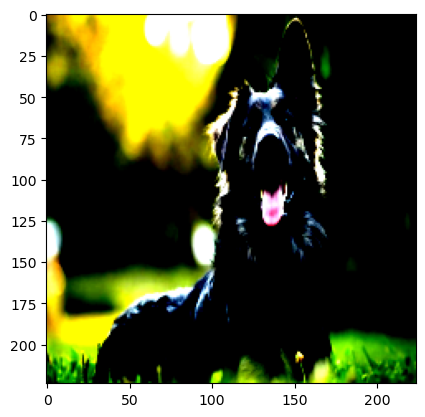

In [8]:
plt.imshow(black_dog[0].cpu().squeeze().transpose(0,2).transpose(0,1).float())

In [9]:
#res = vit_wrapper.forward_features(white_img_unsq.to("cuda"), make_2D=True)
res = vit_wrapper.forward_features(black_dog[0].to("cuda"), make_2D=True)

In [10]:
res.shape

torch.Size([1, 384, 16, 16])

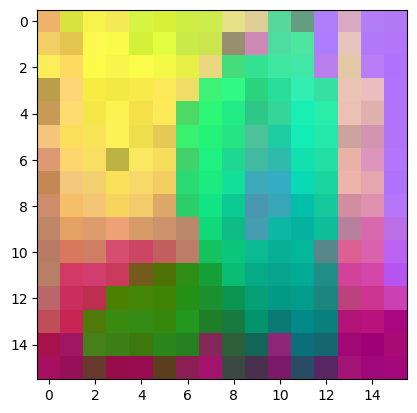

In [11]:
reduced_feats = do_2D_pca(res[0,::], n_components=3, post_norm="minmax")
plt.imshow(reduced_feats)

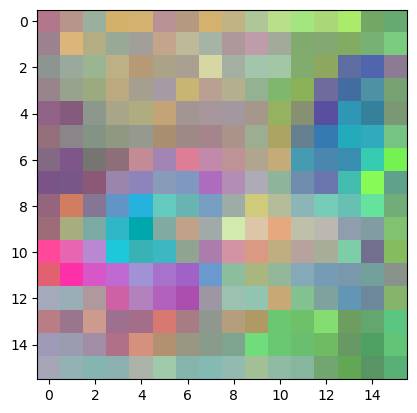

In [12]:
plt_img = np.transpose(res.detach().cpu().numpy().squeeze()[[1,4,10],:,:], (2,1,0)).astype(np.float32)

scaled_plt_img = ((plt_img - plt_img.min())/(plt_img.max()-plt_img.min()))
plt.imshow(scaled_plt_img)

In [13]:
#plt.hist(res.flatten().detach().cpu().numpy(), bins=200)

Model testing

In [14]:
from model import PEModel

vit_wrapper = PEModel.load_from_checkpoint("/home/ab_aimd_anja_20884/Pawlowsky_Moritz/England/DINOMO/testing_dinov2/models/test-epoch=19-val_loss=0.23.ckpt")

In [15]:
res = vit_wrapper(black_dog[0].float().to("cuda"))
#res = vit_wrapper(white_img_unsq.float().to("cuda"))

In [38]:
res.shape

torch.Size([1, 384, 16, 16])

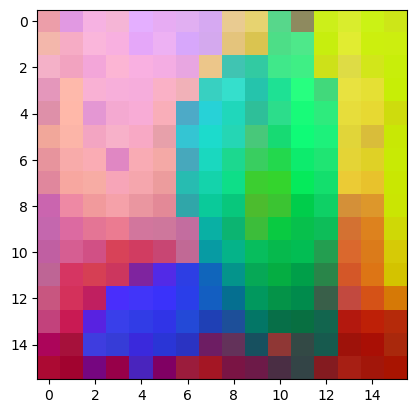

In [39]:
reduced_feats = do_2D_pca(res.squeeze().cpu(), n_components=3, post_norm="minmax")
plt.imshow(reduced_feats)

# testing how to homogenise vit output

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8779297..2.640625].


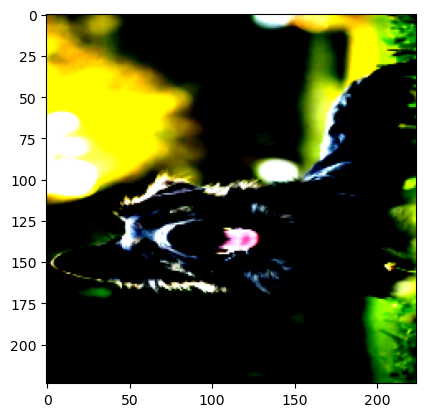

In [28]:
plt.imshow(black_dog[0].cpu().squeeze().transpose(0,2).float())

In [46]:
test_img = black_dog[0]#.flip(0,3)#.transpose(2,3)
#test_img = white_img_unsq.to("cuda")
res_orig = vit_wrapper.forward_features(test_img, make_2D=True)
pca_res_orig = do_2D_pca(res_orig.squeeze(), post_norm="minmax")

#test_img_flip = black_dog[0].flip(0,3)#.transpose(2,3)
test_img_flip = test_img.flip(0,3).to("cuda")
res_flip = vit_wrapper.forward_features(test_img_flip, make_2D=True)
pca_res_flip = do_2D_pca(res_flip.flip(0,3).squeeze(), post_norm="minmax")

#test_img_flip2 = black_dog[0].flip(0,2)#.transpose(2,3)
test_img_flip2 = test_img.flip(2,3).to("cuda")
res_flip2 = vit_wrapper.forward_features(test_img_flip2, make_2D=True)
pca_res_flip2 = do_2D_pca(res_flip2.flip(2,3).squeeze(), post_norm="minmax")

test_img_flip3 = test_img.flip(2,3).flip(0,3).to("cuda")
res_flip3 = vit_wrapper.forward_features(test_img_flip3, make_2D=True)
pca_res_flip3 = do_2D_pca(res_flip3.flip(0,3).flip(2,3).squeeze(), post_norm="minmax")

mean_res = (pca_res_flip + pca_res_orig + pca_res_flip2 + pca_res_flip3) / 4

In [44]:
test_img.shape

torch.Size([1, 3, 224, 224])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8779297..2.640625].


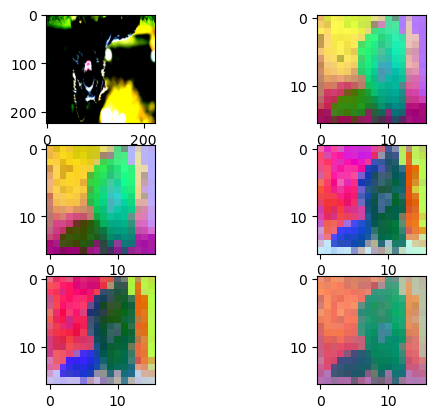

In [ ]:
fig, axes = plt.subplots(3,2)

for ax, img in zip(axes.ravel(), [test_img_flip2.detach().cpu().squeeze().transpose(0,2).transpose(0,1).float(),pca_res_orig, 
                                  pca_res_flip, pca_res_flip2,
                                  pca_res_flip3, mean_res]):
    ax.imshow(img)
# vertical flipping doesnt do anything??

# testing trained vit

In [17]:
trained_model = PEModel.load_from_checkpoint("models/test-epoch=15-val_loss=0.45.ckpt")

In [23]:
res  = trained_model(black_dog[0].to("cuda").float()).cpu()

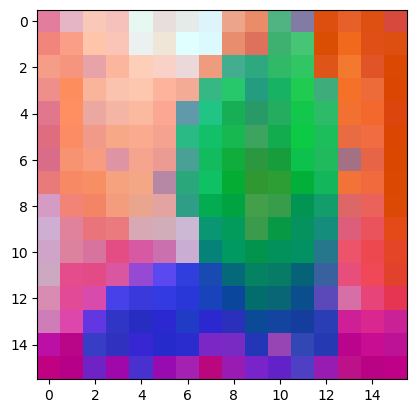

In [25]:
res_pca = do_2D_pca(res.squeeze(), post_norm="minmax")
plt.imshow(res_pca)